# NB01: MedMentions Data Foundation (Zero-to-Hero)

## What
We build the data foundation for a biomedical GraphRAG system using the real Hugging Face dataset `bigbio/medmentions`.

## Why
GraphRAG quality is capped by data quality. If the ingest schema is noisy, every downstream stage (chunking, graph construction, retrieval, and generation) degrades.

## When
Use this workflow when you need a biomedical corpus with real entity annotations (UMLS concept IDs) and want to avoid synthetic data.

## Tradeoffs
- **All official splits vs train-only**: all splits maximize corpus coverage for GraphRAG, but reduce strict train/test separation for model training tasks.
- **Keep raw schema vs normalize schema**: raw schema is faster to start, normalized schema is safer for reproducible pipelines.

## Alternatives
- **NCBI Disease**: great quality, but narrow entity scope.
- **BC5CDR**: useful for disease/chemical, but not broad enough for graph-based biomedical exploration.
- **PubTator exports**: broad, but requires additional parsing and quality checks.

## Production Considerations
- Persist normalized records with versioning.
- Track exact data slice and random seed.
- Keep schema stable so downstream jobs do not silently break.

In [1]:
# Input: notebook runtime and project source directory.
# Output: deterministic imports and plotting defaults.
# Logic: set up environment once at notebook start.
# Complexity: O(1).
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.config import settings
from src.data_pipeline import load_medmentions_records, persist_records
from src.utils import save_plot, timed_block

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Project root: {settings.project_root}")
print(f"Processed directory: {settings.processed_dir}")

Project root: /home/ahmad/AI/Medical-Research-GraphRAG
Processed directory: /home/ahmad/AI/Medical-Research-GraphRAG/data/processed


## Step 1: Load Real MedMentions Records

### Definition
A **record** is one PubMed document (PMID) with title, abstract, and manually curated entity mentions mapped to UMLS concept IDs.

### Why this step matters
Every later artifact should be traceable to real source records. We do not use any synthetic augmentation in this project.

In [2]:
# Input: max_records configuration (5000 cap, real records only).
# Output: normalized record list with title, abstract, text, and entities.
# Logic: load official train/validation/test splits and normalize fields.
# Complexity: O(N) over records.
with timed_block("Load MedMentions"):
    records = load_medmentions_records(max_records=settings.max_records)

print(f"Total normalized records: {len(records):,}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigbio/medmentions' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Using the latest cached version of the dataset since bigbio/medmentions couldn't be found on the Hugging Face Hub


Found the latest cached dataset configuration 'medmentions_full_source' at /home/ahmad/.cache/huggingface/datasets/bigbio___medmentions/medmentions_full_source/1.0.0/4ed5b6a69d807969022e559198c5a7386b9a978268a558758a090db6b451d6c4 (last modified on Fri Jun 19 17:48:19 2026).


2026-06-22 09:39:42 | INFO | Loaded 4392 normalized MedMentions records across all splits
2026-06-22 09:39:42 | INFO | load_medmentions_records completed in 6.14s
2026-06-22 09:39:42 | INFO | Load MedMentions completed in 6.14s
Total normalized records: 4,392


## Step 2: Inspect Schema and Example Record

### What
We inspect the normalized structure to make sure we know exactly what downstream code will consume.

### Why
Debugging late-stage graph or retrieval failures is expensive. Early schema checks are cheap.

In [3]:
# Input: first normalized record.
# Output: readable schema preview.
# Logic: show key fields and example entity annotations.
# Complexity: O(1).
example = records[0]
print("PMID:", example.pmid)
print("Split:", example.split)
print("Title preview:", example.title[:140])
print("Abstract preview:", example.abstract[:300])
print("Entity count:", len(example.entities))
print("First 5 entities:")
for entity in example.entities[:5]:
    print(
        f"  text={entity.text!r} | concept_id={entity.concept_id} | semantic_types={entity.semantic_type_ids[:3]}"
    )

PMID: 25763772
Split: train
Title preview: DCTN4 as a modifier of chronic Pseudomonas aeruginosa infection in cystic fibrosis
Abstract preview: Pseudomonas aeruginosa (Pa) infection in cystic fibrosis (CF) patients is associated with worse long-term pulmonary disease and shorter survival, and chronic Pa infection (CPA) is associated with reduced lung function, faster rate of lung decline, increased rates of exacerbations and shorter surviva
Entity count: 98
First 5 entities:
  text='DCTN4' | concept_id=C4308010 | semantic_types=['T116', 'T123']
  text='chronic Pseudomonas aeruginosa infection' | concept_id=C0854135 | semantic_types=['T047']
  text='cystic fibrosis' | concept_id=C0010674 | semantic_types=['T047']
  text='Pseudomonas aeruginosa (Pa) infection' | concept_id=C0854135 | semantic_types=['T047']
  text='cystic fibrosis' | concept_id=C0010674 | semantic_types=['T047']


## Step 3: Corpus-Level Diagnostics

### What
We compute distribution statistics required for chunking and graph planning.

### Why
- Text length distribution informs chunk size.
- Entity density informs graph sparsity.
- Split ratios explain where records come from.

In [4]:
# Input: normalized records list.
# Output: pandas stats table.
# Logic: aggregate split counts, char lengths, and entity counts.
# Complexity: O(N).
rows = []
for record in records:
    rows.append(
        {
            "pmid": record.pmid,
            "split": record.split,
            "text_chars": len(record.text),
            "title_chars": len(record.title),
            "abstract_chars": len(record.abstract),
            "entity_count": len(record.entities),
        }
    )

df = pd.DataFrame(rows)
summary = (
    df.groupby("split")
    .agg(
        records=("pmid", "count"),
        avg_text_chars=("text_chars", "mean"),
        median_text_chars=("text_chars", "median"),
        avg_entity_count=("entity_count", "mean"),
    )
    .reset_index()
)
summary

,split,records,avg_text_chars,median_text_chars,avg_entity_count
0,test,879,1585.407281,1628.0,80.096701
1,train,2635,1579.297533,1603.0,80.086907
2,validation,878,1593.219818,1594.5,80.936219


## Step 4: Visualize Length and Entity Distributions

### Why these charts
- Length histogram prevents accidentally choosing chunk sizes that over-fragment text.
- Entity histogram estimates graph node/edge density and long-tail behavior.

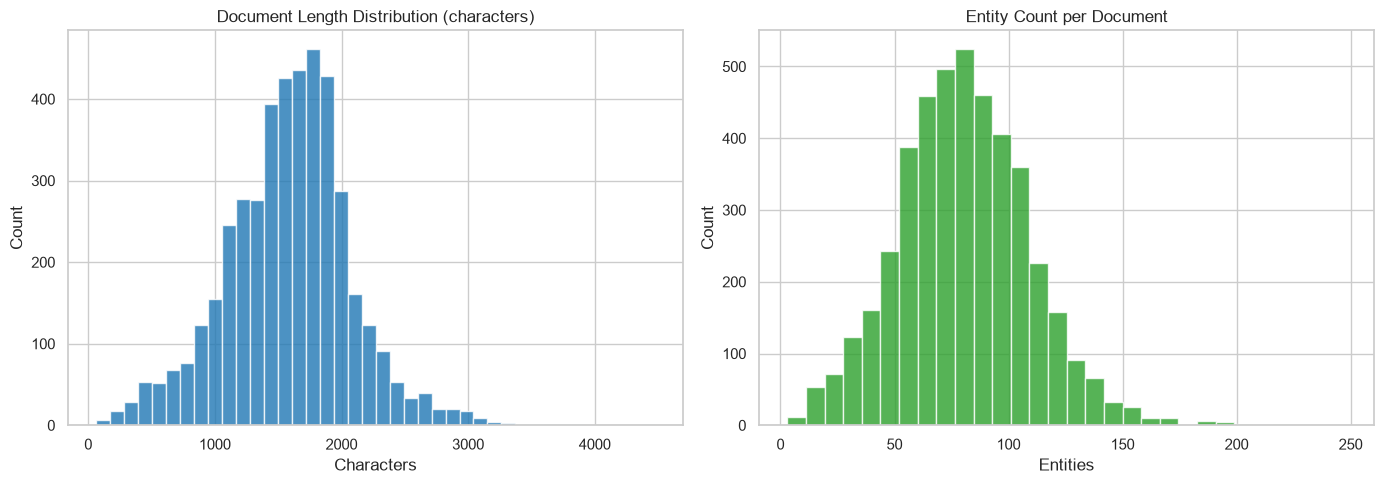

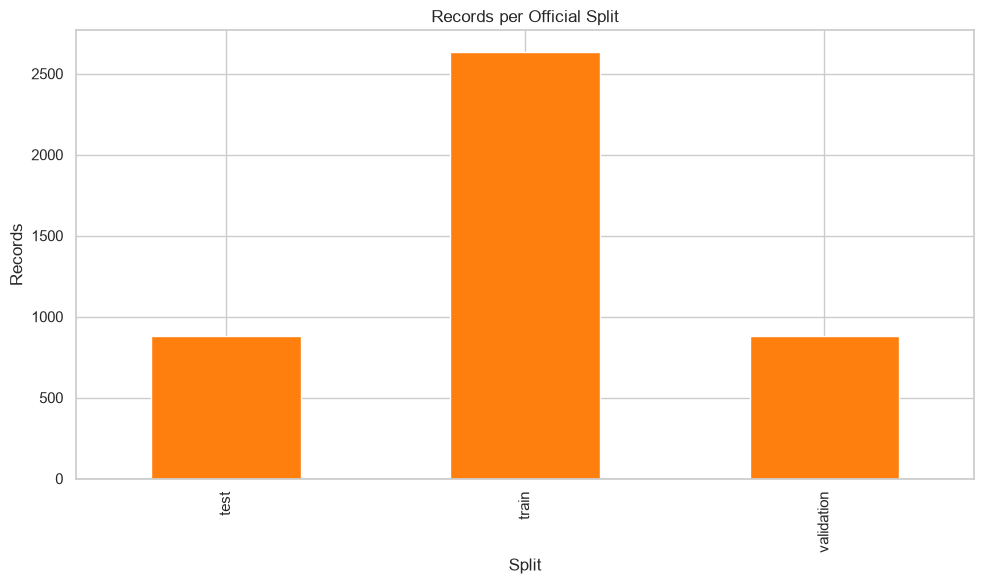

In [5]:
# Input: dataframe with text and entity counts.
# Output: saved figures for README and later notebooks.
# Logic: build histograms and split-level bar chart.
# Complexity: O(N).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["text_chars"], bins=40, color="#1f77b4", alpha=0.8)
axes[0].set_title("Document Length Distribution (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(df["entity_count"], bins=30, color="#2ca02c", alpha=0.8)
axes[1].set_title("Entity Count per Document")
axes[1].set_xlabel("Entities")
axes[1].set_ylabel("Count")

save_plot(settings.figures_dir / "nb01_length_entity_distributions.png")
plt.show()

split_counts = df["split"].value_counts().sort_index()
ax = split_counts.plot(kind="bar", color="#ff7f0e", title="Records per Official Split")
ax.set_xlabel("Split")
ax.set_ylabel("Records")
save_plot(settings.figures_dir / "nb01_split_counts.png")
plt.show()

## Step 5: UMLS Concept and Semantic-Type Coverage

### Definition
- **Concept ID (CUI)**: canonical UMLS identifier, for example `C0011849` for diabetes mellitus.
- **Semantic Type ID (TUI)**: high-level biomedical category.

### Why
GraphRAG can exploit concept IDs directly for entity-centric traversal.

In [6]:
# Input: entity annotations from all records.
# Output: top concept and semantic-type tables.
# Logic: flatten nested entities and count frequencies.
# Complexity: O(total_entities).
concept_counter = Counter()
semantic_counter = Counter()

for record in records:
    for entity in record.entities:
        concept_counter[entity.concept_id] += 1
        for semantic_id in entity.semantic_type_ids:
            semantic_counter[semantic_id] += 1

concept_df = pd.DataFrame(concept_counter.most_common(20), columns=["concept_id", "mentions"])
semantic_df = pd.DataFrame(semantic_counter.most_common(20), columns=["semantic_type_id", "mentions"])

print(f"Unique concept IDs: {len(concept_counter):,}")
print(f"Unique semantic type IDs: {len(semantic_counter):,}")
concept_df.head(10)

Unique concept IDs: 34,724
Unique semantic type IDs: 127


,concept_id,mentions
0,C0030705,5897
1,C2603343,2140
2,C0243095,1925
3,C0087111,1662
4,C0332281,1300
5,C0205556,1248
6,C0392762,1236
7,C0441833,1203
8,C0936012,1192
9,C1274040,1044


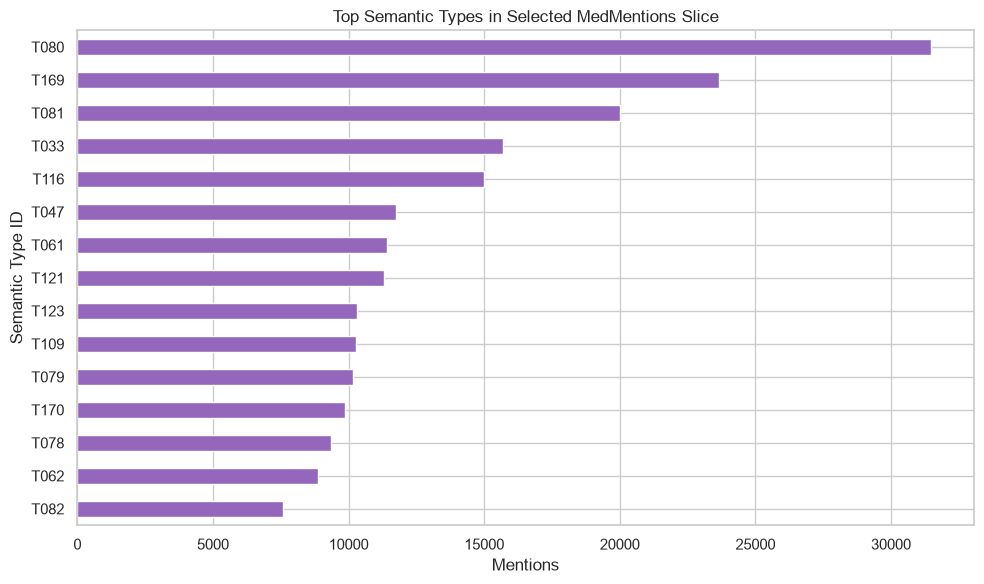

In [7]:
# Input: semantic type frequency table.
# Output: saved semantic-type chart.
# Logic: horizontal bar plot for readability.
# Complexity: O(K) for top-k semantic types.
ax = semantic_df.head(15).sort_values("mentions").plot(
    kind="barh",
    x="semantic_type_id",
    y="mentions",
    color="#9467bd",
    legend=False,
    title="Top Semantic Types in Selected MedMentions Slice",
)
ax.set_xlabel("Mentions")
ax.set_ylabel("Semantic Type ID")
save_plot(settings.figures_dir / "nb01_top_semantic_types.png")
plt.show()

## Step 6: Persist Normalized Records for Downstream Notebooks

### What
Save normalized records once so NB02+ never need to re-parse raw dataset structure.

### Why
This removes repeated boilerplate, reduces error surface, and keeps notebook execution deterministic.

In [8]:
# Input: in-memory normalized records.
# Output: `data/processed/medmentions_records.json`.
# Logic: serialize dataclass objects to JSON.
# Complexity: O(N).
output_path = persist_records(records)
print("Saved normalized records:", output_path)

# Persist summary tables for README usage.
summary.to_csv(settings.tables_dir / "nb01_split_summary.csv", index=False)
concept_df.to_csv(settings.tables_dir / "nb01_top_concepts.csv", index=False)
semantic_df.to_csv(settings.tables_dir / "nb01_top_semantic_types.csv", index=False)
print("Saved NB01 tables to:", settings.tables_dir)

2026-06-22 09:39:48 | INFO | Saved normalized records to /home/ahmad/AI/Medical-Research-GraphRAG/data/processed/medmentions_records.json
2026-06-22 09:39:48 | INFO | persist_records completed in 5.43s
Saved normalized records: /home/ahmad/AI/Medical-Research-GraphRAG/data/processed/medmentions_records.json
Saved NB01 tables to: /home/ahmad/AI/Medical-Research-GraphRAG/outputs/tables


## Notebook Recap

You now have:
1. Real MedMentions records across all official splits.
2. Stable normalized schema ready for chunking.
3. Distribution diagnostics and saved figures.
4. Persisted JSON + CSV artifacts for reproducible downstream stages.

Next: `NB02_Chroma_GraphRAG` builds chunking + embeddings, persists Chroma vectors,
and adds relationship-aware graph construction for GraphRAG local/global search.